# Getting started with PyDDA

`pyanalog` is Anabrid's toolkit for programming analog computers. Its core module, `dda` (short for *digital differential analyzer*), lets you describe a circuit as Python code built out of the same primitives an analog computer actually has: `sum`, `mult`, `neg`, `int` (integrate), and a handful of others (`min`, `max`, `sqrt`, ...).

A `dda.State` is just a dictionary mapping variable names to the expression that computes them — i.e. the circuit's wiring. Once you have a `State` you can:

- turn it back into a normal equation (`sympy`/`latex` export) — the "circuit → equation" direction, or
- simulate it numerically with `scipy` to see what it would actually do if built, or
- export it to C++/DDA/FPAA config to run on real hardware.

One important physical detail baked into the primitives: on a real analog computer, **summers and integrators are inverting**. `dda.sum(a, b)` computes `-(a+b)`, and `dda.int(a, dt, ic)` computes the negative integral. That's why you'll see `dda.neg(...)` wrapped around sums below — it's the second op-amp stage (an inverter) that a real circuit needs to undo the sign flip.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dda import State, Symbol, symbols, dda, export
from dda.scipy import to_scipy

%matplotlib inline

## 1. A static circuit: `y = m*x + b`

This is the simplest possible "circuit": a scaling multiply plus a bias, i.e. a summing amplifier followed by an inverter. No dynamics, no integrators — just algebra.

In [2]:
x, m, b, y = symbols("x, m, b, y")

s = State()
s[y] = dda.neg(dda.sum(dda.mult(m, x), b))

s  # the circuit, as a DDA expression

State({'y': neg(sum(mult(m, x), b))})

### Circuit → equation

`export(..., to="sympy")` walks the circuit and gives you back a normal symbolic equation — useful for sanity-checking that the circuit you wired actually computes what you meant.

In [3]:
export(s, to="sympy")

[Eq(y, b + m*x)]

In [4]:
print(export(s, to="latex"))

\begin{align}
y &= b + m x
\end{align}


### Circuit → hardware

`export(..., to="schematic")` goes one step further than the sympy/latex export above: instead of an equation, it renders an actual analog-computer block schematic — an SVG built from op-amp symbols, coefficient/multiplier blocks, and wires — based on the linearized computing-element graph. It's not something the DDA algebra layer used to have any way to produce; `dda.State.draw_graph()` only ever drew the abstract expression tree. This is the missing translation step from "the algebra is right" to "here's what to build."

Each computing element becomes exactly one block, so the picture stays 1:1 traceable to the DDA code: `sum`/`neg`/`int` become op-amp triangles, a `mult` with one literal operand becomes a labeled coefficient, a `mult` of two live signals becomes a multiplier-IC block, and anything without a canonical op-amp circuit (`sqrt`, `min`, the comparators, ...) is drawn as a dashed amber box — flagged as needing hand-designed shaping circuitry rather than silently guessing one.

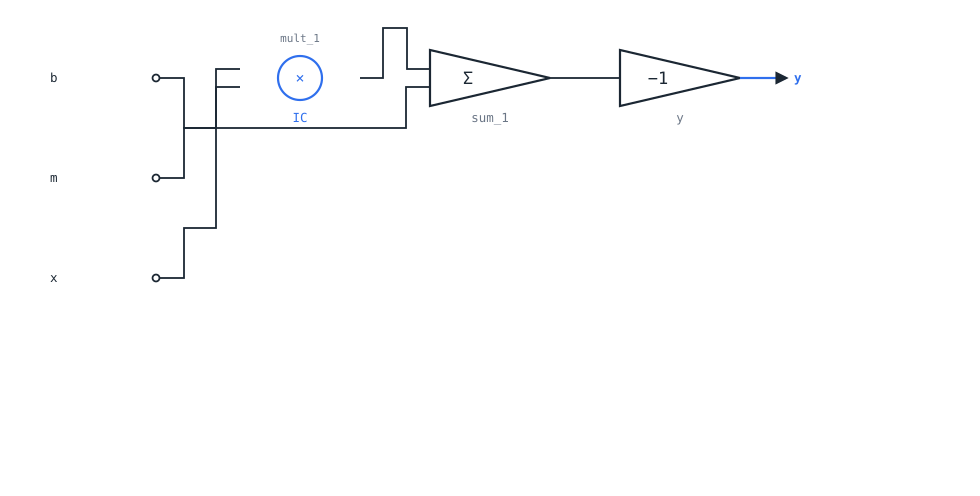

In [5]:
pic = export(s, to="schematic")
pic  # renders inline via _repr_svg_ in Jupyter

# pic.save("y_mx_b.svg")  # or write it out to build from

## 2. A dynamic circuit: exponential decay

Static algebra doesn't need an analog computer — a resistor network already does that. Analog computers earn their keep on *differential* equations, via the integrator block. Here's the simplest possible dynamic circuit: a single integrator feeding back on itself, giving `dx/dt = -x`.

`dda.int(x, dt, ic)` means "integrate `x` (negated), with timestep `dt` and initial condition `ic`". Note that for the `scipy` simulation backend, `dt` only has to be *consistent* across every integrator in the circuit — SciPy's adaptive solver picks its own actual step size, `dt` here isn't used for that.

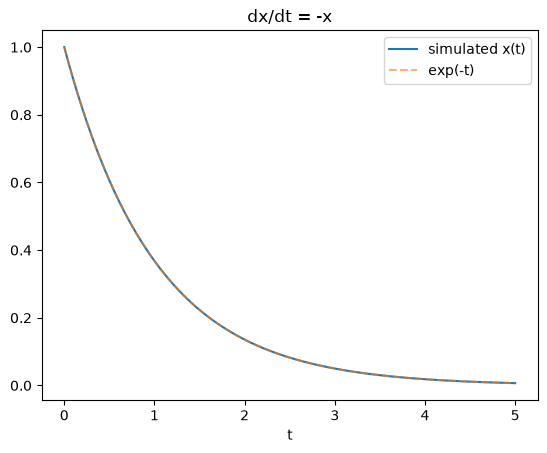

In [6]:
xx = Symbol("xx")

decay = State()
decay[xx] = dda.int(xx, 1, 1)  # dx/dt = -x, x(0) = 1

decay_sim = to_scipy(decay)
sol = decay_sim.solve(5, dense_output=True)

t = np.linspace(0, 5, 200)
plt.plot(t, sol.sol(t)[0], label="simulated x(t)")
plt.plot(t, np.exp(-t), "--", label="exp(-t)", alpha=0.6)
plt.xlabel("t"); plt.legend(); plt.title("dx/dt = -x");

## 3. A classic analog computer circuit: the harmonic oscillator

Two integrators cross-coupled with a sign flip is the textbook analog-computer way to solve `y'' = -y` (a sine/cosine generator) — this exact pattern shows up throughout `examples/`. It's a nice example because it's a genuinely *second order* system built from nothing but the same primitives as above.

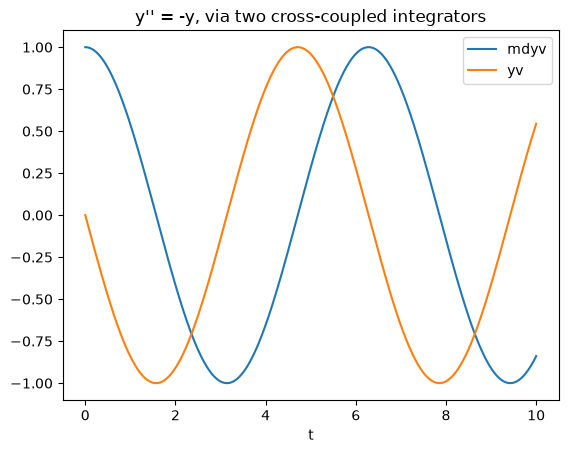

In [7]:
yv, myv, mdyv = symbols("yv, myv, mdyv")
dt = 1

osc = State()
osc[myv]  = dda.neg(yv)               # myv = -yv
osc[yv]   = dda.int(mdyv, dt, 0)      # dyv/dt  = -mdyv,  yv(0)  = 0
osc[mdyv] = dda.int(myv, dt, 1)       # dmdyv/dt = -myv,  mdyv(0) = 1

osc_sim = to_scipy(osc)
sol = osc_sim.solve(10, dense_output=True, max_step=0.05)

t = np.linspace(0, 10, 400)
values = sol.sol(t)

plt.figure()

for i, name in enumerate(osc_sim.vars.evolved):
    plt.plot(t, values[i], label=name)

plt.xlabel("t");
plt.legend();
plt.title("y'' = -y, via two cross-coupled integrators");

The oscillator is a better demonstration of the schematic exporter than the static circuit above, because it actually has a feedback loop. The exporter detects the cycle `myv → yv → mdyv → myv` (a plain left-to-right layered layout can't draw a cycle) and renders the closing edge as an arcing wire back over the top of the block it feeds — exactly the convention a hand-drawn feedback resistor/capacitor loop uses.

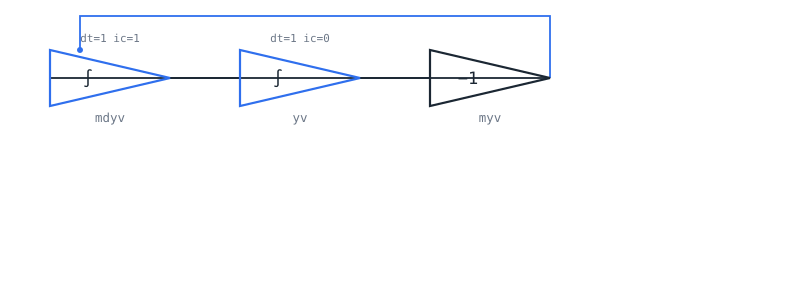

In [8]:
export(osc, to="schematic")

## Where to go from here

- `examples/python-dda-circuits/` in this repo has bigger worked examples (population dynamics, N-body, a heat equation).
- `export(state, to="cpp")` / `to="CppSolver"` compiles the circuit to C++ if you want a faster or standalone simulation.
- The `fpaa/` module (`PyFPAA`) is the next step: compiling a circuit like the ones above into actual hardware configuration — digital potentiometer and crossbar-switch settings — for a field-programmable analog array.